1. Business Context
The objective of this notebook is to transform transactional retail data into customer-level behavioral features suitable for unsupervised learning techniques such as clustering and dimensionality reduction.

In [39]:
#2. Import Libraries
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

In [ ]:

#3. Load Data
df_09_10 = pd.read_excel(
    "../data/raw/online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

df_10_11 = pd.read_excel(
    "../data/raw/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

# Merge datasets

df = pd.concat(
    [df_09_10, df_10_11],
    ignore_index=True
)

# Dataset shape

print(f"Dataset shape: {df.shape}")

Dataset shape: (1067371, 8)


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


The original dataset is divided into two worksheets corresponding to different time periods.
Both datasets are loaded and merged into a single transactional dataset to provide a complete historical view of customer purchasing behavior.

4. Data Cleaning

In [8]:
#4.1 Remove Missing Customer IDs
df = df.dropna(subset=['Customer ID'])
df.shape

(824364, 8)

In [11]:
#4.2 Remove Cancelled Transactions
df = df[
    ~df['Invoice'].astype(str).str.startswith('C')
]
df.shape

(805620, 8)

In [12]:
#4.3 Remove Negative Quantities
df = df[df['Quantity'] > 0]
df.shape

(805620, 8)

In [ ]:
#4.4 Remove Non-Positive Prices
df = df[df["Price"] > 0]
df.shape

(805549, 8)

In [14]:
#5. Create Total Amount
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [ ]:
#6. Create Snapshot Date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [17]:
#7. Build RFM Table
rfm = df.groupby('Customer ID').agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

In [ ]:
#Rename Columns
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [23]:
#8. Advanced Features

avg_order_value = (
    df.groupby("Customer ID")["TotalPrice"]
    .mean()
)

basket_size = (
    df.groupby("Customer ID")["Quantity"]
    .mean()
)

customer_lifetime = (
    df.groupby("Customer ID")["InvoiceDate"]
    .agg(lambda x: (x.max() - x.min()).days)
)


In [25]:
rfm["AvgOrderValue"] = avg_order_value

rfm["BasketSize"] = basket_size

rfm["CustomerLifetime"] = customer_lifetime

rfm.head()

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
Customer ID,,,,,,
12346.0,326,12,77556.46,2281.072353,2184.852941,400
12347.0,2,8,5633.32,22.266087,12.988142,402
12348.0,75,5,2019.40,39.596078,53.215686,362
12349.0,19,4,4428.69,25.306800,9.280000,570
12350.0,310,1,334.40,19.670588,11.588235,0


# 10. Outlier Analysis

This section evaluates the presence of extreme values within the customer behavioral features.
Outliers are particularly important in customer segmentation problems because high-value customers can strongly influence clustering algorithms.

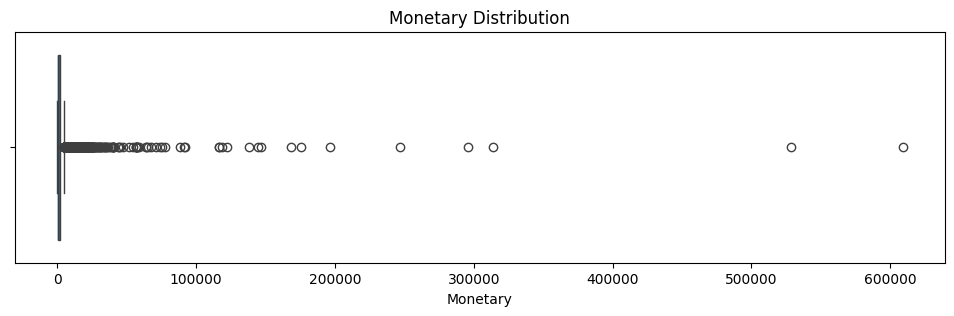

In [ ]:
plt.figure(figsize=(12,3))
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Distribution")
plt.show()

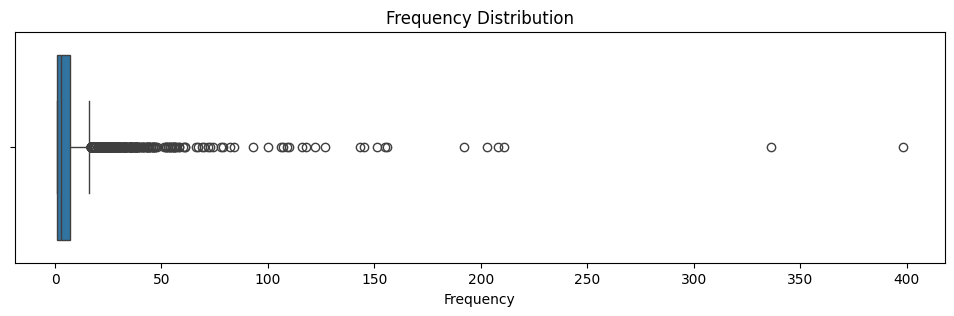

In [31]:
plt.figure(figsize=(12,3))
sns.boxplot(x=rfm["Frequency"])
plt.title("Frequency Distribution")
plt.show()

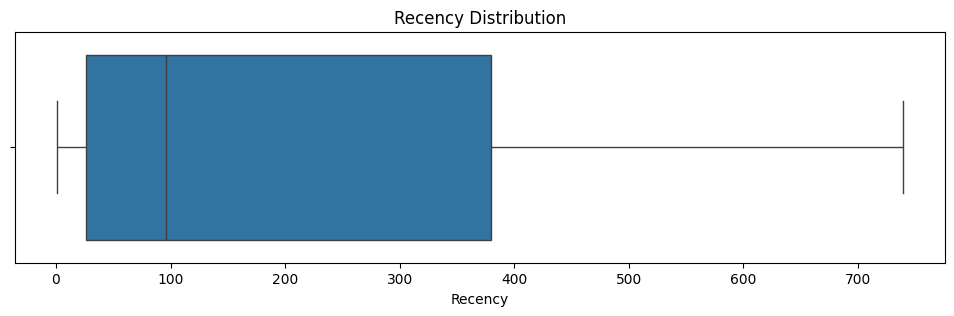

In [ ]:
plt.figure(figsize=(12,3))
sns.boxplot(x=rfm["Recency"])
plt.title("Recency Distribution")
plt.show()

In [ ]:
#11. Log Transformation
rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])
rfm_log["AvgOrderValue"] = np.log1p(rfm_log["AvgOrderValue"])
rfm_log["BasketSize"] = np.log1p(rfm_log["BasketSize"])
rfm_log["CustomerLifetime"] = np.log1p(rfm_log["CustomerLifetime"])

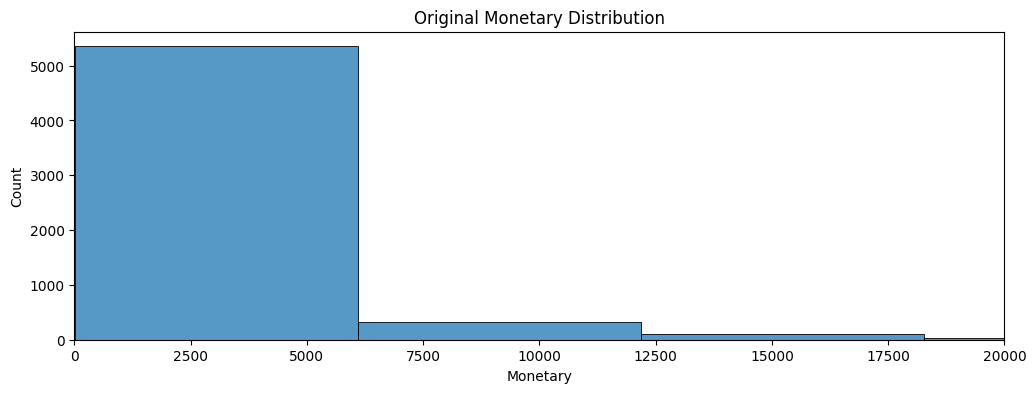

In [ ]:
plt.figure(figsize=(12,4))
sns.histplot(rfm["Monetary"], bins=100)
plt.xlim(0, 20000)
plt.title("Original Monetary Distribution")

plt.show()

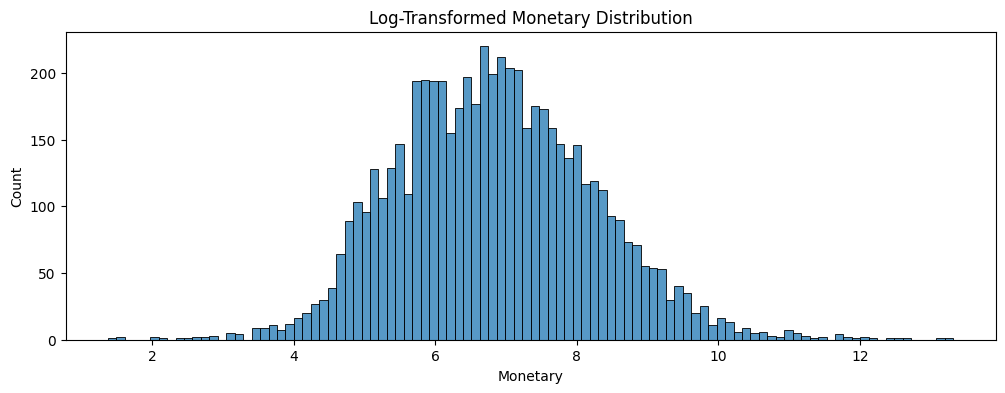

In [38]:
plt.figure(figsize=(12,4))

sns.histplot(rfm_log["Monetary"], bins=100)

plt.title("Log-Transformed Monetary Distribution")

plt.show()

# 12. Feature Scaling

Feature scaling is a critical preprocessing step for clustering algorithms because distance-based models are highly sensitive to variable magnitudes.
Standardization was applied to ensure that all customer behavioral features contribute equally during clustering.

In [43]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
Customer ID,,,,,,
12346.0,0.856701,1.254496,3.186625,5.676270,6.232787,0.741024
12347.0,-2.151979,0.800166,1.297127,0.225443,0.294860,0.742876
12348.0,-0.079138,0.299207,0.558100,0.887118,1.887334,0.703977
12349.0,-0.935308,0.073946,1.123790,0.371442,-0.067195,0.872539
12350.0,0.824527,-1.058146,-0.735888,0.084847,0.170910,-1.489407


In [44]:
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
count,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00
mean,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.41,-1.06,-3.94,-2.19,-1.99,-1.49
25%,-0.74,-1.06,-0.71,-0.52,-0.59,-1.49
50%,0.08,-0.20,-0.02,-0.06,-0.03,0.52
75%,0.95,0.65,0.65,0.32,0.39,0.83
max,1.38,5.48,4.67,9.48,9.19,0.97


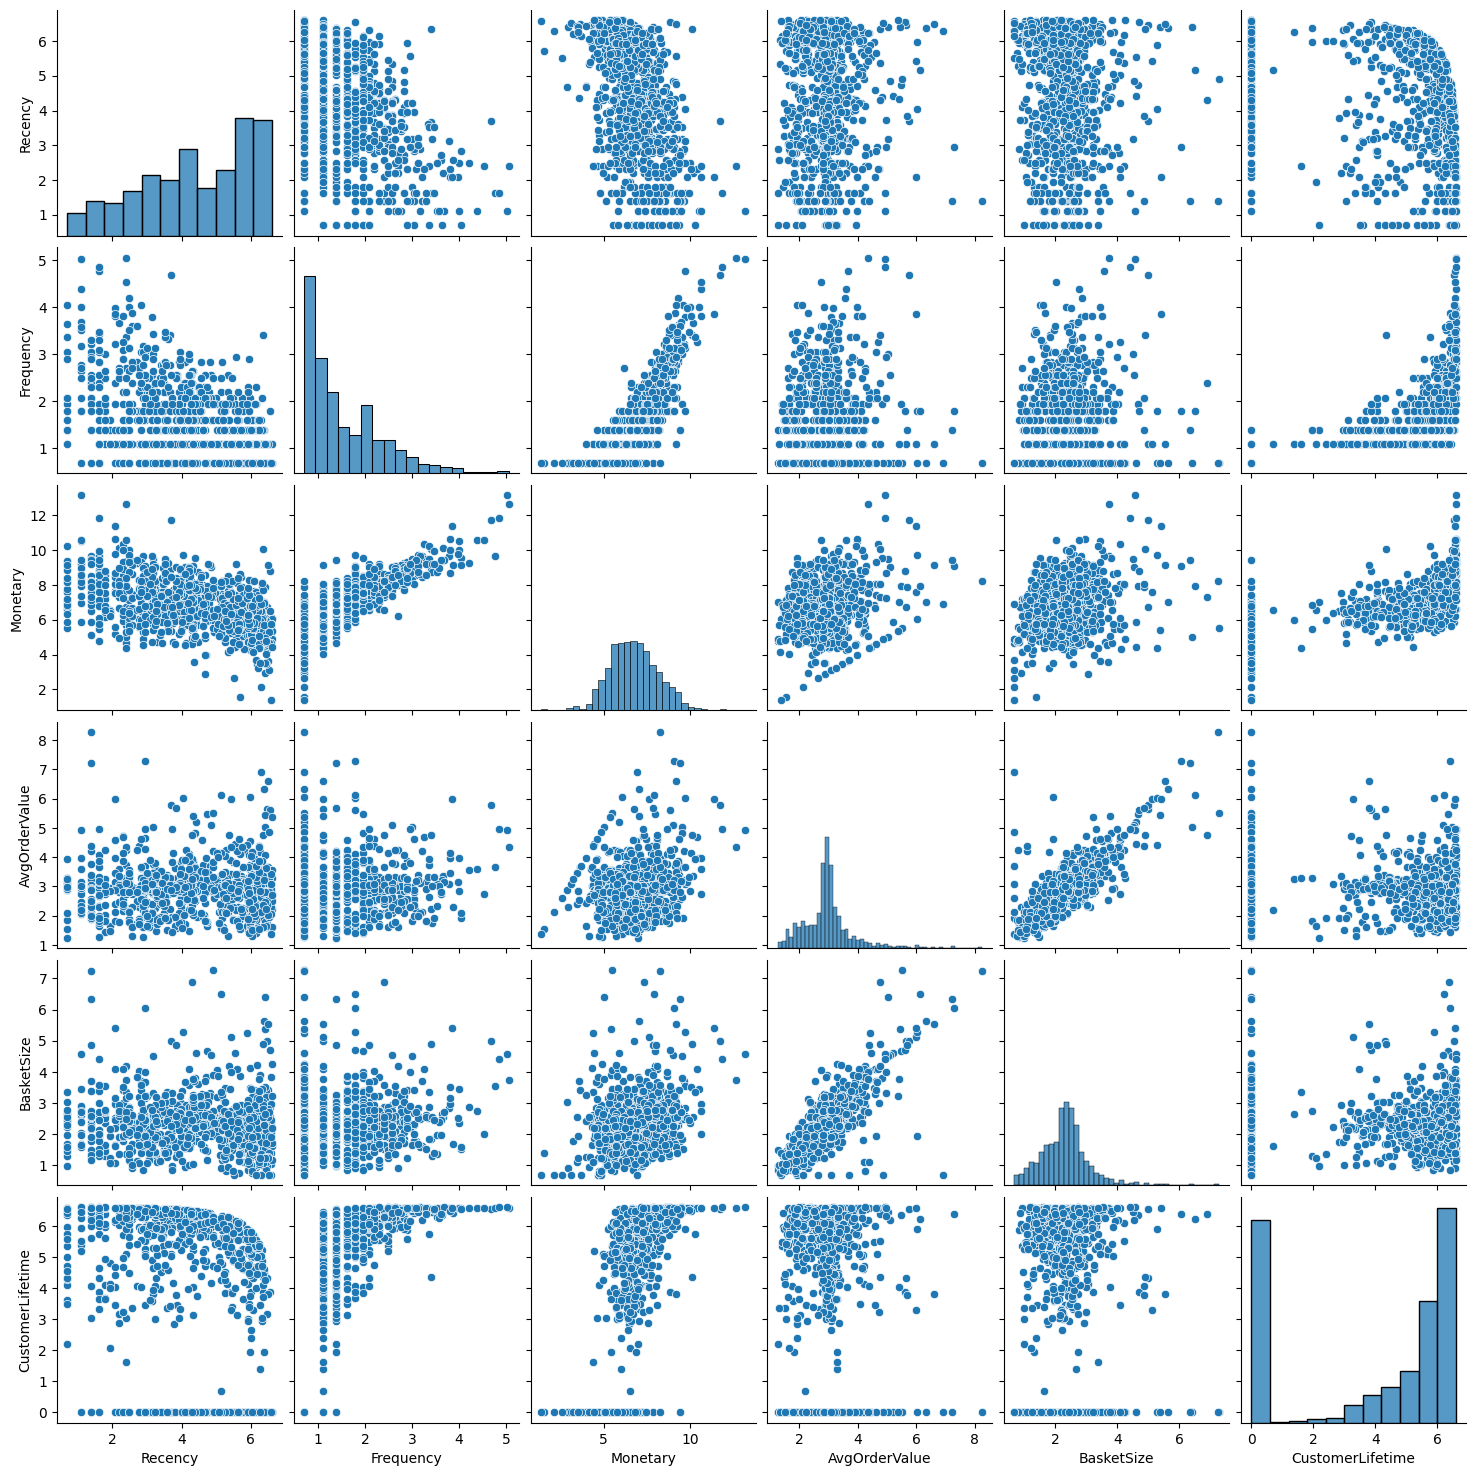

In [45]:
sample_rfm = rfm_log.sample(1000, random_state=42)

sns.pairplot(sample_rfm)

plt.show()

# 13. Final Dataset Inspection

The final machine learning dataset contains cleaned, transformed, and standardized customer-level behavioral features suitable for clustering and dimensionality reduction techniques.

In [46]:
rfm_scaled.shape

(5878, 6)

In [47]:
rfm_scaled.head()

,Recency,Frequency,Monetary,AvgOrderValue,BasketSize,CustomerLifetime
Customer ID,,,,,,
12346.0,0.856701,1.254496,3.186625,5.676270,6.232787,0.741024
12347.0,-2.151979,0.800166,1.297127,0.225443,0.294860,0.742876
12348.0,-0.079138,0.299207,0.558100,0.887118,1.887334,0.703977
12349.0,-0.935308,0.073946,1.123790,0.371442,-0.067195,0.872539
12350.0,0.824527,-1.058146,-0.735888,0.084847,0.170910,-1.489407


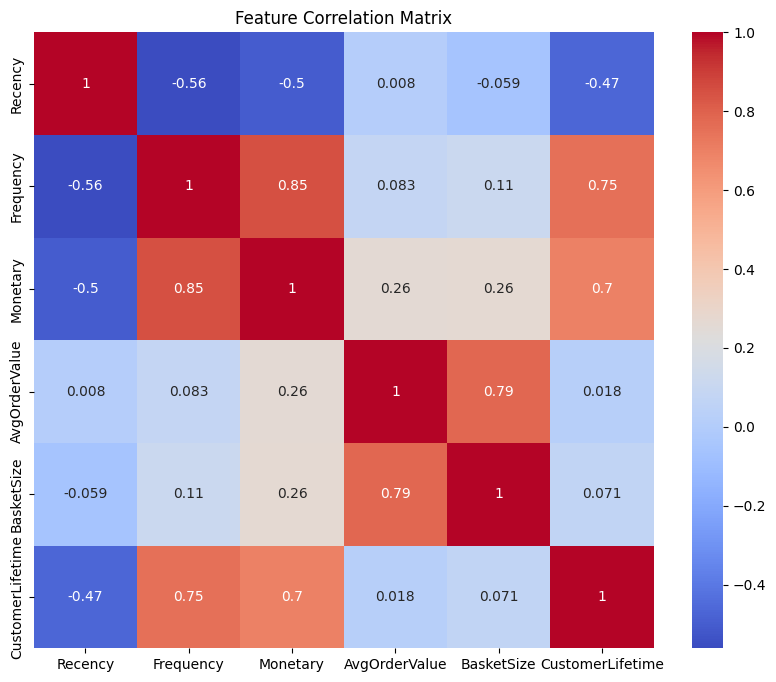

In [48]:
plt.figure(figsize=(10,8))

sns.heatmap(
    rfm_log.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

# 14. Save Processed Data

The processed datasets are exported for reuse in subsequent clustering and dimensionality reduction notebooks.

In [49]:
rfm_log.to_csv(
    "../data/processed/rfm_log.csv"
)

In [50]:
rfm_scaled.to_csv(
    "../data/processed/rfm_scaled.csv"
)